## Neural Network Approach

Now we will bild a neural network taking a character and predicting the next character (same as bigram model but with learned weights). 

In [1]:
import os

fpath = os.path.join('..', 'names.txt')
words = open(fpath, 'r').read().splitlines()

In [20]:
import torch

SE_TOKEN = '.'

chars = sorted(list(set(''.join(words)))) 
stoi = {s: i for i, s in enumerate(chars, start=1)}
stoi[SE_TOKEN] = 0
itos = {i: s for s, i in stoi.items()}

# Create the training set of bigrams
xs, ys = [], []

for w in words[:1]:
    chs = [SE_TOKEN] + list(w) + [SE_TOKEN]
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

xs = torch.tensor(xs)
ys = torch.tensor(ys)

print(xs)
print(ys)
print(xs.dtype)

tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])
torch.int64


In [26]:
# Convert the input into one-hot encoding
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).float()
print(xenc.shape)
print(xenc.dtype)
print(xenc)

torch.Size([5, 27])
torch.float32
tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])


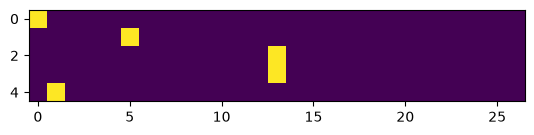

In [27]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(xenc)

In [ ]:
# Our neural network will consist of a single layer
# Let's create 27 neurons with randomly initialized weights
W = torch.randn(27, 27)
xenc @ W

# (5, 27) @ (27, 27) --> (5, 27)

tensor([[ 1.2641,  0.5125, -0.1605, -0.1012,  0.1079, -0.2864, -0.2328, -0.3215,
          2.1002, -0.1754, -0.3736,  1.2942, -1.6450, -0.1843,  0.7991, -0.8375,
         -0.5960,  0.7668, -0.2062,  0.0390,  0.7481, -0.5892,  0.7117,  0.0810,
          0.4151,  0.7793,  1.0698],
        [ 0.4878,  0.3190, -0.6655,  0.1527, -0.0170,  0.6918,  0.5227, -2.1270,
          0.0717,  1.4412, -0.8803, -0.2091, -1.5495, -0.6961,  0.6671, -0.7562,
         -0.9703,  0.5130, -1.6652, -0.3261, -0.0134, -0.4532,  0.0398, -1.6758,
          2.2356, -0.1174, -0.7576],
        [ 0.4267, -1.7086, -1.0411,  2.5090,  0.0058, -0.6460, -0.7932, -1.7888,
         -0.4569, -1.4789,  1.2627,  0.0316,  0.2495,  1.0781,  2.0561, -1.2571,
         -0.2550, -0.0267, -1.1591, -1.5878, -0.2282, -0.3381,  1.4503,  0.6313,
          0.6477,  0.6674,  0.2483],
        [ 0.4267, -1.7086, -1.0411,  2.5090,  0.0058, -0.6460, -0.7932, -1.7888,
         -0.4569, -1.4789,  1.2627,  0.0316,  0.2495,  1.0781,  2.0561, -1.2571

In [52]:
print((xenc @ W)[0, 1])
print((xenc[0] * W[:, 1]).sum())

tensor(0.5125)
tensor(0.5125)
